In [1]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
# Purpose: 1. Silence warnings for a clean output.
#          2. Mount Google Drive and connect to the Golden Master DB.
#          3. Apply the "Opus Lab" Visual Canon (Standardized Aesthetics).
# ==============================================================================

# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None  # Silence SettingWithCopy

# --- 2. IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from google.colab import drive

# --- 3. CONNECTIVITY ---
print("⏳ Mounting Google Drive...")
try:
    drive.mount('/content/drive')
    print("✅ Drive Mounted.")
except:
    print("ℹ️ Drive already mounted or running locally.")

# DEFINITIVE PATH
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db'

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    print(f"✅ Database found: {DB_PATH}")
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ SQL Engine Active.")

# --- 4. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Light Mode).")
print("\n--- SYSTEM READY ---")

⏳ Mounting Google Drive...
Mounted at /content/drive
✅ Drive Mounted.
✅ Database found: /content/drive/MyDrive/_Pienza/Assets/Database/opus.db
✅ SQL Engine Active.
✅ Visual Identity Loaded: Opus Lab (Light Mode).

--- SYSTEM READY ---


In [2]:
# ==============================================================================
# CELL 1: DATA INGESTION & CORE FILTERING
# ==============================================================================
# 1. Fetch the Core Offers data.
# 2. Apply the strategic "Operational Viability" filter.
# 3. Define the final analytical dataframe.
# ==============================================================================

# --- Query the raw data from the Golden Master ---
query_offers = "SELECT * FROM offers"
df_offers_raw = pd.read_sql(query_offers, db_engine)
print(f"✅ Fetched {len(df_offers_raw)} raw offers from opus.db")

# --- Query the rejection reasons to filter ---
query_reasons = "SELECT reason_primary_id, reason_primary_description FROM reason_primary"
df_reasons = pd.read_sql(query_reasons, db_engine)

# Get the ID for the Geo-Veto
geo_veto_id = df_reasons[df_reasons['reason_primary_description'] == 'dropoff_non_operational']['reason_primary_id'].iloc[0]

# --- THE CRITICAL FILTER ---
df_viable = df_offers_raw[df_offers_raw['reason_primary_fk'] != geo_veto_id].copy()
print(f"✅ Filtered out Geo-Vetoes. Remaining viable offers: {len(df_viable)}")

# --- Define the analytical dataframe ---
df_analysis = df_viable.copy()
print("\n--- Analytical Dataframe Ready ---")

✅ Fetched 4765 raw offers from opus.db
✅ Filtered out Geo-Vetoes. Remaining viable offers: 2399

--- Analytical Dataframe Ready ---


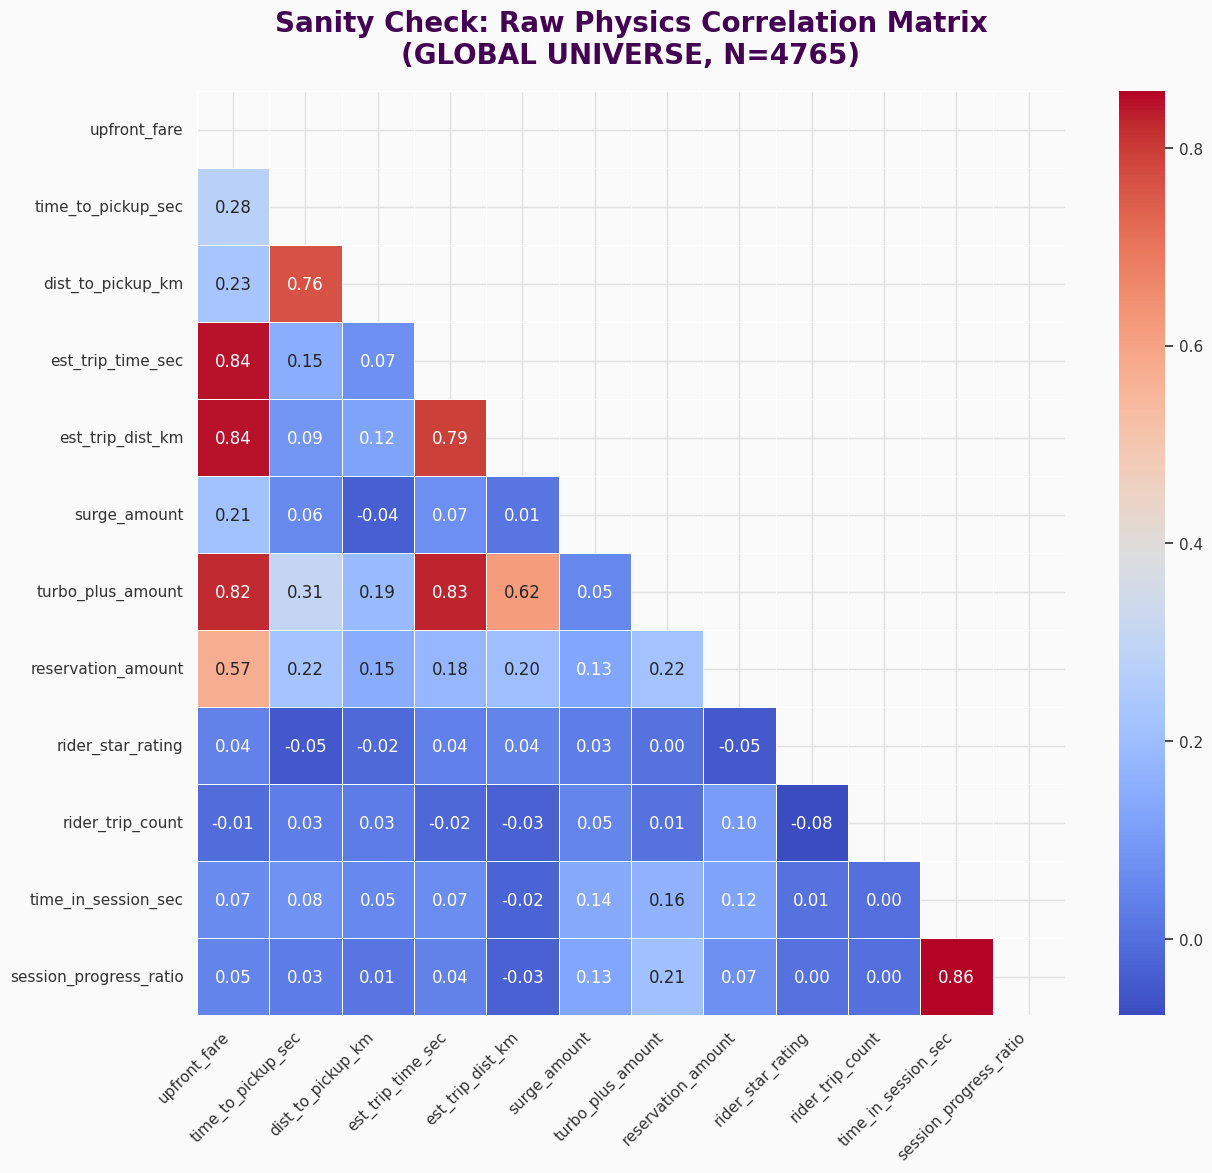

In [3]:
# ==============================================================================
# CELL 2: SANITY CHECK - "RAW PHYSICS" CORRELATION MATRIX (GLOBAL UNIVERSE)
# ==============================================================================
# Purpose: Re-generate the original correlation heatmap on the FULL dataset
#          to investigate the anomalous -0.50 correlation of Rider Star Rating.
# ==============================================================================

# --- Define the "Raw Physics" columns ---
physics_cols = [
    'upfront_fare',
    'time_to_pickup_sec',
    'dist_to_pickup_km',
    'est_trip_time_sec',
    'est_trip_dist_km',
    'surge_amount',
    'turbo_plus_amount',
    'reservation_amount',
    'rider_star_rating',
    'rider_trip_count',
    'time_in_session_sec',
    'session_progress_ratio'
]

# --- Calculate the correlation matrix ON THE RAW, UNFILTERED DATA ---
corr_matrix_physics = df_offers_raw[physics_cols].corr()

# --- Visualize the heatmap ---
plt.figure(figsize=(14, 12))

# Create a mask to hide the upper triangle
mask = np.triu(np.ones_like(corr_matrix_physics, dtype=bool))

sns.heatmap(corr_matrix_physics,
            mask=mask,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=.5)

plt.title('Sanity Check: Raw Physics Correlation Matrix\n(GLOBAL UNIVERSE, N=4765)', fontsize=20, pad=20, color=OPUS_PURPLE)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

✅ Fetched 4765 rows from engineered_features.


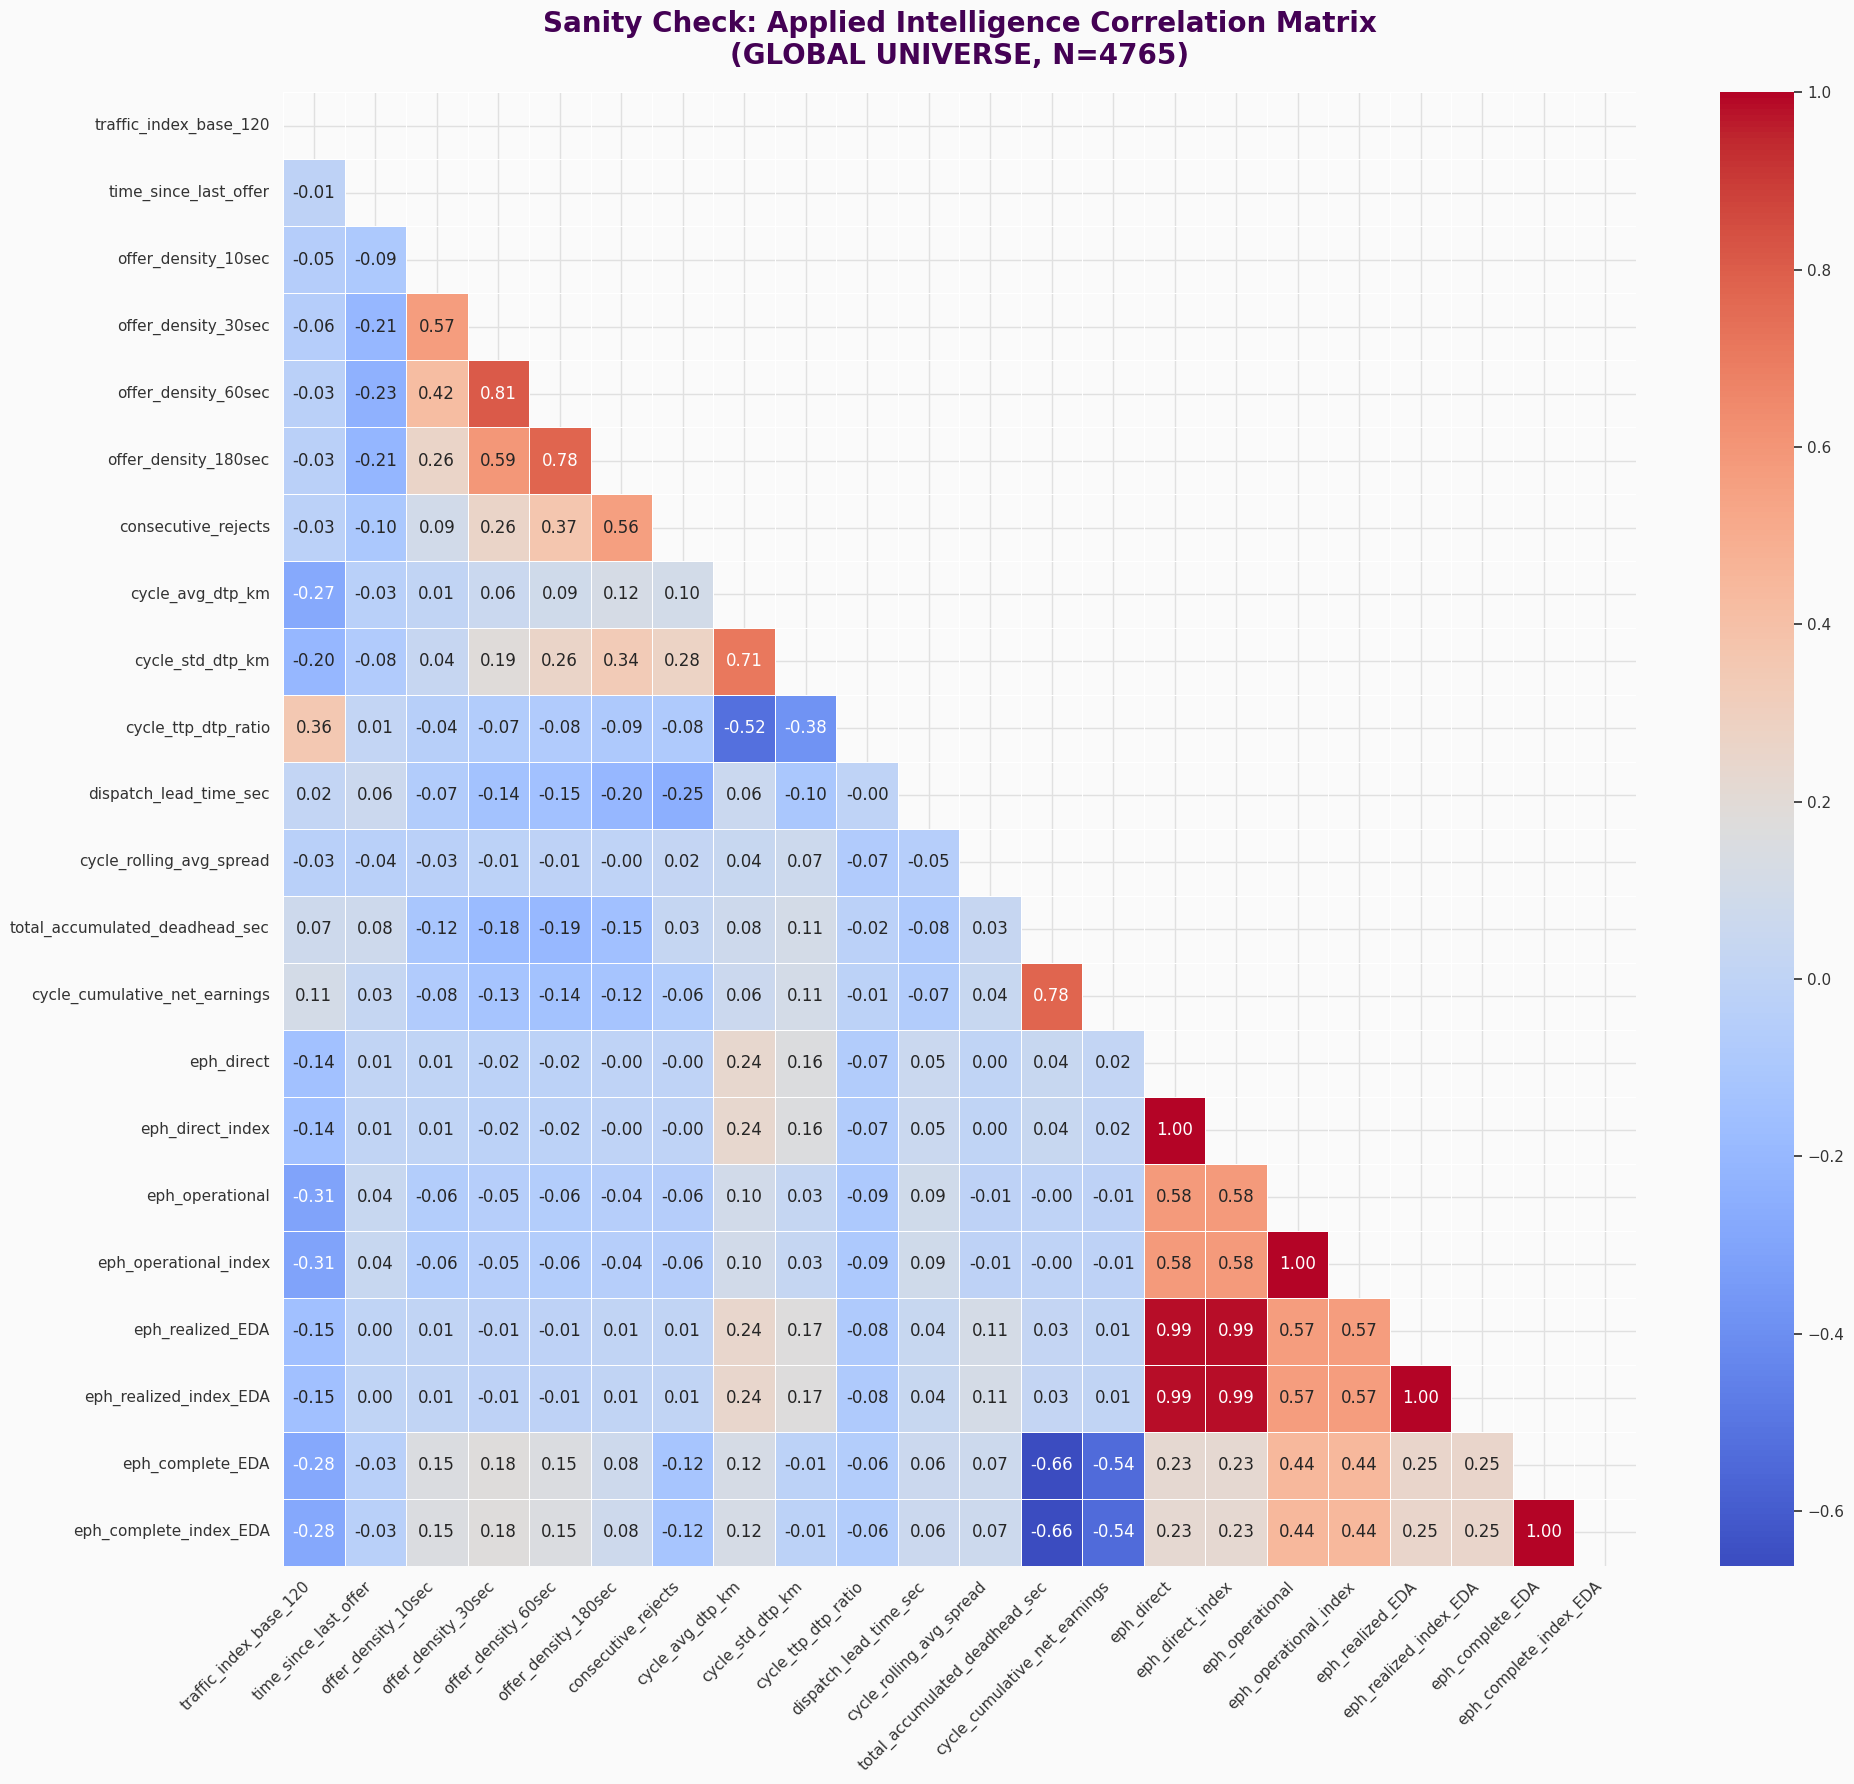

In [4]:
# ==============================================================================
# CELL 3: SANITY CHECK - "APPLIED INTELLIGENCE" CORRELATION MATRIX (GLOBAL)
# ==============================================================================
# Purpose: Generate the correlation heatmap for the FULL engineered_features
#          table to audit the structural collinearity of our custom features.
#          NO FILTERS, NO .dropna() ALLOWED.
# ==============================================================================

# --- Query the full engineered features table from the Golden Master ---
query_features = """
SELECT
    traffic_index_base_120,
    time_since_last_offer,
    offer_density_10sec,
    offer_density_30sec,
    offer_density_60sec,
    offer_density_180sec,
    consecutive_rejects,
    cycle_avg_dtp_km,
    cycle_std_dtp_km,
    cycle_ttp_dtp_ratio,
    dispatch_lead_time_sec,
    cycle_rolling_avg_spread,
    total_accumulated_deadhead_sec,
    cycle_cumulative_net_earnings,
    eph_direct,
    eph_direct_index,
    eph_operational,
    eph_operational_index,
    eph_realized_EDA,
    eph_realized_index_EDA,
    eph_complete_EDA,
    eph_complete_index_EDA
FROM engineered_features
"""
df_features_raw = pd.read_sql(query_features, db_engine)
print(f"✅ Fetched {len(df_features_raw)} rows from engineered_features.")

# --- Calculate the correlation matrix (Pandas handles NULLs pairwise) ---
corr_matrix_features = df_features_raw.corr()

# --- Visualize the heatmap ---
plt.figure(figsize=(20, 18)) # Bigger plot for more variables

# Create a mask to hide the upper triangle
mask = np.triu(np.ones_like(corr_matrix_features, dtype=bool))

sns.heatmap(corr_matrix_features,
            mask=mask,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=.5)

plt.title('Sanity Check: Applied Intelligence Correlation Matrix\n(GLOBAL UNIVERSE, N=4765)', fontsize=20, pad=20, color=OPUS_PURPLE)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

⏳ Loading Completed Trips Audit data...
✅ Auditing 123 completed missions.


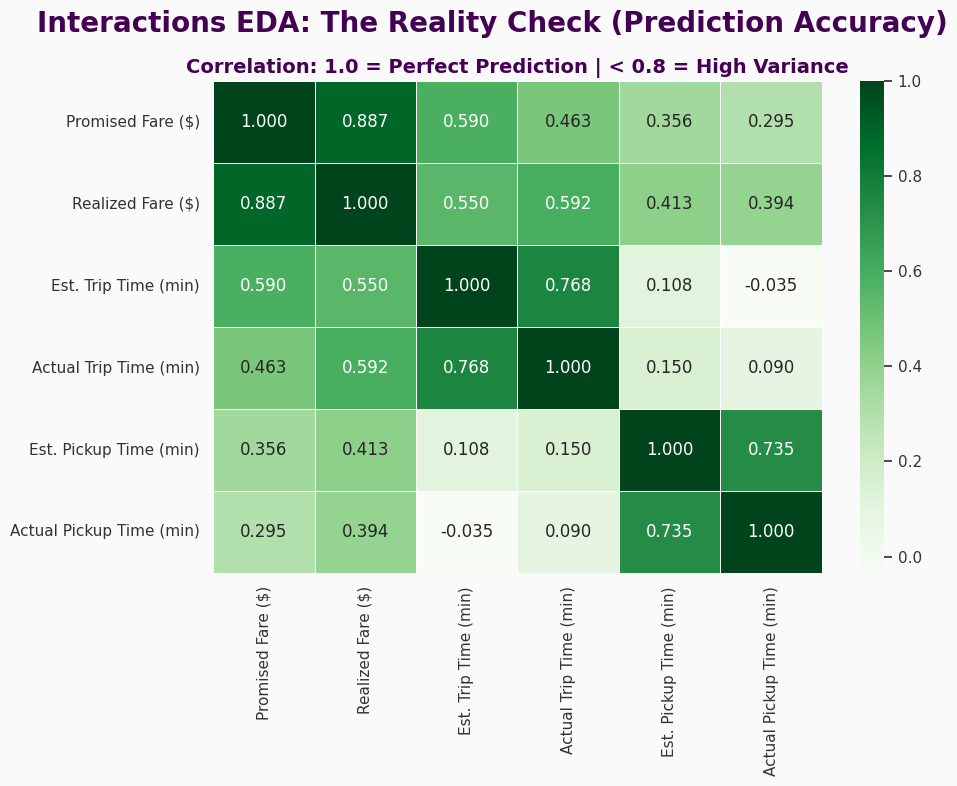

In [5]:
# ==============================================================================
# CELL 6: THE REALITY CHECK MATRIX (PROMISE VS. EXECUTION)
# ==============================================================================
# Purpose: To audit the accuracy of the platform's predictions.
#          Correlates "Upfront/Estimated" metrics (X) against "Actual/Realized"
#          metrics (Y) for the subset of COMPLETED TRIPS.
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. LOAD DATA (JOINING PROMISE AND REALITY)
print("⏳ Loading Completed Trips Audit data...")
# We join 'offers' (Promise) with 'v_trip_final_kpis' (Reality) via the dossier view
query = """
SELECT
    -- FINANCIALS
    o.upfront_fare              AS "Promised Fare ($)",
    kpi.realized_fare           AS "Realized Fare ($)",

    -- TRIP DURATION
    (o.est_trip_time_sec / 60)  AS "Est. Trip Time (min)",
    (kpi.duration_trip_sec / 60) AS "Actual Trip Time (min)",

    -- PICKUP FRICTION
    (o.time_to_pickup_sec / 60) AS "Est. Pickup Time (min)",
    (kpi.duration_to_pickup_sec / 60) AS "Actual Pickup Time (min)"

FROM v_mission_dossier kpi
JOIN offers o ON kpi.offer_id = o.offer_id
WHERE o.upfront_fare IS NOT NULL
  AND kpi.realized_fare IS NOT NULL
"""
df_reality = pd.read_sql(query, db_engine).dropna()

print(f"✅ Auditing {len(df_reality)} completed missions.")

# 2. CALCULATE CORRELATION
corr_matrix_real = df_reality.corr(method='pearson')

# 3. PLOTTING CONFIGURATION
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle('Interactions EDA: The Reality Check (Prediction Accuracy)', fontsize=20, color='#440154', weight='bold', y=0.98)

# 4. HEATMAP
# We only care about the correlations between Promise and Reality, but the full matrix shows cross-effects too.
sns.heatmap(
    corr_matrix_real,
    annot=True,
    fmt=".3f",
    cmap='Greens', # Green for "Truth/Accuracy"
    cbar=True,
    linewidths=0.5,
    linecolor='white',
    ax=ax
)

ax.set_title("Correlation: 1.0 = Perfect Prediction | < 0.8 = High Variance", fontsize=14)

plt.tight_layout()
plt.show()

## 🛑 **STOP:** The Eureka Moment (`Heatmap Correlation`)

### **Context: The "Reality Check"**
During the `Interactions EDA` module, a global correlation heatmap (see visualization above) was generated to audit the integrity of the platform's predictive signals.

### **The Signal:**
A specific cell in the matrix triggered an immediate red flag:
*   **Correlation(`Est. Trip Time` vs. `Actual Trip Time`) = `0.768`**

In most datasets, `0.768` is a "strong" correlation. **In this domain, it is a catastrophic signal.**
It implies that the platform's core prediction of labor effort (`Est. Trip Time`) explains only ~59% ($R^2$) of the variance in the actual realized labor (`Actual Trip Time`).

**Comparison for Context:**
*   `Promised Fare` vs. `Realized Fare` = `0.887` (Financial stability is relatively high).
*   `Estimated Time` vs. `Realized Time` = `0.768` (Operational stability is significantly lower).

### **The Breakthrough Hypothesis ("The Transfer of Variance"):**
This disparity (`0.887` vs. `0.768`) is the "smoking gun" of the **Gig Economy Risk Transfer Thesis.**
1.  **The Platform hedges the Price:** It maintains high correlation on the fare to keep the driver's financial trust relatively stable.
2.  **The Platform floats the Time:** It allows significant variance in the trip duration to be absorbed by the driver.

**If the Price is fixed but the Time expands, the Driver's hourly wage (`EPH`) collapses.**

### **Strategic Action Triggered:**
This single datapoint halted the linear progression of the EDA. It mandated the immediate creation of the **"Promise vs. Reality" SQL Analysis** (`Double Spread Analysis`) to calculate the granular `time_spread` for every trip. This pivot is the origin point of the **"Algorithmic Deductible"** analytical campaign.

### 💎 Strategic Breakthrough: The "Variance Deductible"

**The Correction:**
Profitability in high-traffic zones is NOT impossible, provided the friction is **predicted and priced** at the moment of the offer (Priced Entropy).

**The Real Trap (Unpriced Volatility):**
The danger lies in **Prediction Error**. The forensic analysis of `Time Spread` (Actual / Estimated) reveals that the platform transfers the risk of *unexpected* delays to the driver up to a specific threshold.

1.  **The Deductible Zone (1.0x to ~1.3x Time):**
    *   If a trip takes **up to 30% longer** than the initial quote (due to an accident, rain, or bad GPS data), the fare remains fixed.
    *   **Implication:** The Agent fully absorbs the cost of this "Surprise Friction."

2.  **Strategic Verdict:**
    The deadliest zones are not necessarily those with the highest traffic (Gridlock), but those with the **least predictable traffic** (High Variance). A slow but stable commute is profitable. A volatile route where 20 minutes can turn into 40 minutes is a financial gamble where the driver holds the downside risk and the platform holds the deductible.

⏳ Executing Super-Join Query to create DataFrame 'df'...
✅ Data Loaded. Shape: (2053, 9)
✅ Data types optimized.

Executing Anti-Simpson Protocol: Surge Status Audit
--------------------------------------------------
📈 Correlation (No Surge): 0.867 (N=1452)
📈 Correlation (Surge):    0.824 (N=601)
--------------------------------------------------
✅ VERDICT: No Simpson's Paradox detected. Global trend holds in subgroups.

Generating visualization...


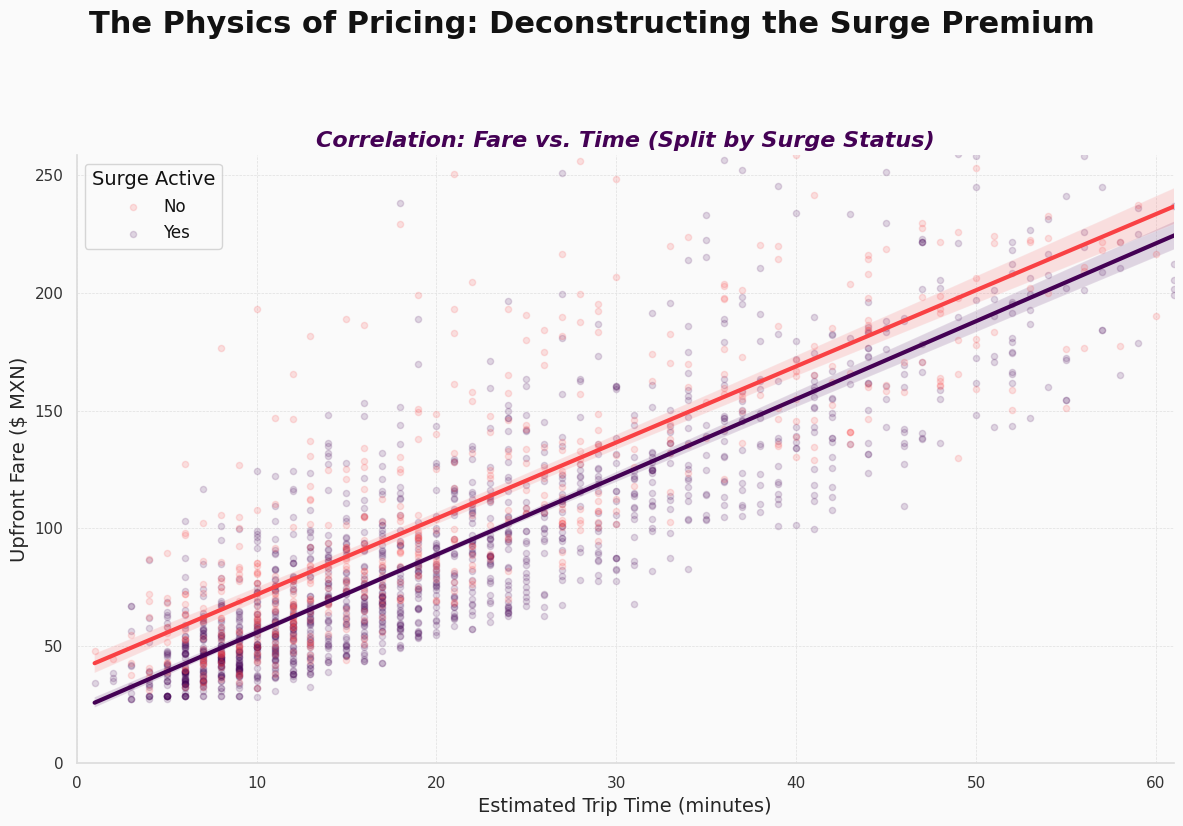


✅ Analysis Complete.


In [6]:
# ==============================================================================
# CELL 2: DATA INGESTION & ANTI-SIMPSON PROTOCOL (TD-EDA-004: SURGE AUDIT)
# ==============================================================================
# Purpose: 1. Load the core analytical dataset from opus.db ("The Super-Join").
#          2. Immediately execute the Anti-Simpson Protocol to deconstruct the
#             relationship between Trip Time and Fare, split by Surge Status.
# ==============================================================================

# --- 1. THE ANALYTICAL QUERY (Data Ingestion) ---
query = """
SELECT
    -- Dimensions (Human Readable Labels)
    pc.category_name                  AS product,
    oa.offer_action_description       AS action,
    rp.reason_primary_description     AS reason,
    ef.day_of_week,
    ef.time_of_day_block,

    -- Core Physics (Raw Offer Attributes)
    o.upfront_fare,
    o.est_trip_time_sec / 60.0        AS est_trip_time_min,
    o.rider_star_rating,

    -- Incentives (The Carrots)
    o.is_surge

FROM offers o
-- Join to the Silver Layer (Features)
LEFT JOIN engineered_features ef  ON o.offer_id = ef.offer_id_fk
-- Join to Dimensions (Decoders)
LEFT JOIN product_category pc     ON o.product_category_fk = pc.product_category_id
LEFT JOIN offer_action oa         ON o.offer_action_fk = oa.offer_action_id
LEFT JOIN reason_primary rp       ON o.reason_primary_fk = rp.reason_primary_id

-- FILTER: Exclude 'Non-Operational' drops (Tier 1 Filter of the Cognitive Cascade)
WHERE rp.reason_primary_description != 'dropoff_non_operational'
"""

print("⏳ Executing Super-Join Query to create DataFrame 'df'...")
df = pd.read_sql(query, db_engine)
print(f"✅ Data Loaded. Shape: {df.shape}")


# --- 2. DATA TYPE CASTING ---
categorical_cols = ['product', 'action', 'reason', 'day_of_week', 'time_of_day_block']
for col in categorical_cols:
    df[col] = df[col].astype('category')

df['is_surge'] = df['is_surge'].fillna(0).astype(bool)
print("✅ Data types optimized.")


# --- 3. QUANTITATIVE ANALYSIS (The Proof) ---
print("\nExecuting Anti-Simpson Protocol: Surge Status Audit")
print("-" * 50)

# Create subgroups
df_no_surge = df[df['is_surge'] == False]
df_surge = df[df['is_surge'] == True]

# Calculate correlation for each subgroup
corr_no_surge = df_no_surge[['est_trip_time_min', 'upfront_fare']].corr().iloc[0, 1]
corr_surge = df_surge[['est_trip_time_min', 'upfront_fare']].corr().iloc[0, 1]

print(f"📈 Correlation (No Surge): {corr_no_surge:.3f} (N={len(df_no_surge)})")
print(f"📈 Correlation (Surge):    {corr_surge:.3f} (N={len(df_surge)})")
print("-" * 50)
if abs(corr_no_surge) > 0.3 and abs(corr_surge) > 0.3:
    print("✅ VERDICT: No Simpson's Paradox detected. Global trend holds in subgroups.")
else:
    print("⚠️ WARNING: Simpson's Paradox may be present. Trend is not consistent.")


# --- 4. VISUALIZATION (The Story) ---
print("\nGenerating visualization...")

# Define a specific palette for this plot to ensure clarity
surge_palette = {False: OPUS_PURPLE, True: '#F94144'} # Opus Purple for baseline, Red for surge

# Use lmplot to create scatter plot with regression lines for each group
g = sns.lmplot(
    data=df,
    x='est_trip_time_min',
    y='upfront_fare',
    hue='is_surge',
    palette=surge_palette,
    height=8,
    aspect=1.5,
    legend=False,
    scatter_kws={'alpha': 0.15, 's': 20},
    line_kws={'linewidth': 3}
)

# --- 5. AESTHETICS & TITLES (The Opus Canon) ---
plt.suptitle("The Physics of Pricing: Deconstructing the Surge Premium", fontsize=22, y=1.03)
plt.title("Correlation: Fare vs. Time (Split by Surge Status)", fontsize=16, style='italic')

plt.xlabel("Estimated Trip Time (minutes)", fontsize=14)
plt.ylabel("Upfront Fare ($ MXN)", fontsize=14)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Custom legend for clarity
# The order of labels is determined by how seaborn plots them, usually True then False.
# We reverse it to match the boolean values for better intuition.
handles, labels = g.ax.get_legend_handles_labels()
plt.legend(handles=handles[::-1], labels=['No', 'Yes'], title='Surge Active', loc='upper left', frameon=True, fontsize=12, title_fontsize=14)

# Set axis limits for better focus, excluding extreme outliers if necessary
plt.xlim(0, df['est_trip_time_min'].quantile(0.99))
plt.ylim(0, df['upfront_fare'].quantile(0.99))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("\n✅ Analysis Complete.")

⏳ Architecting the Unified DataFrame...
✅ Unified DataFrame created. Shape: (4765, 34)
⏳ Calculating the Grand Unified Correlation Matrix...
✅ Correlation Matrix Calculated.
🎨 Rendering the Mega-Heatmap...


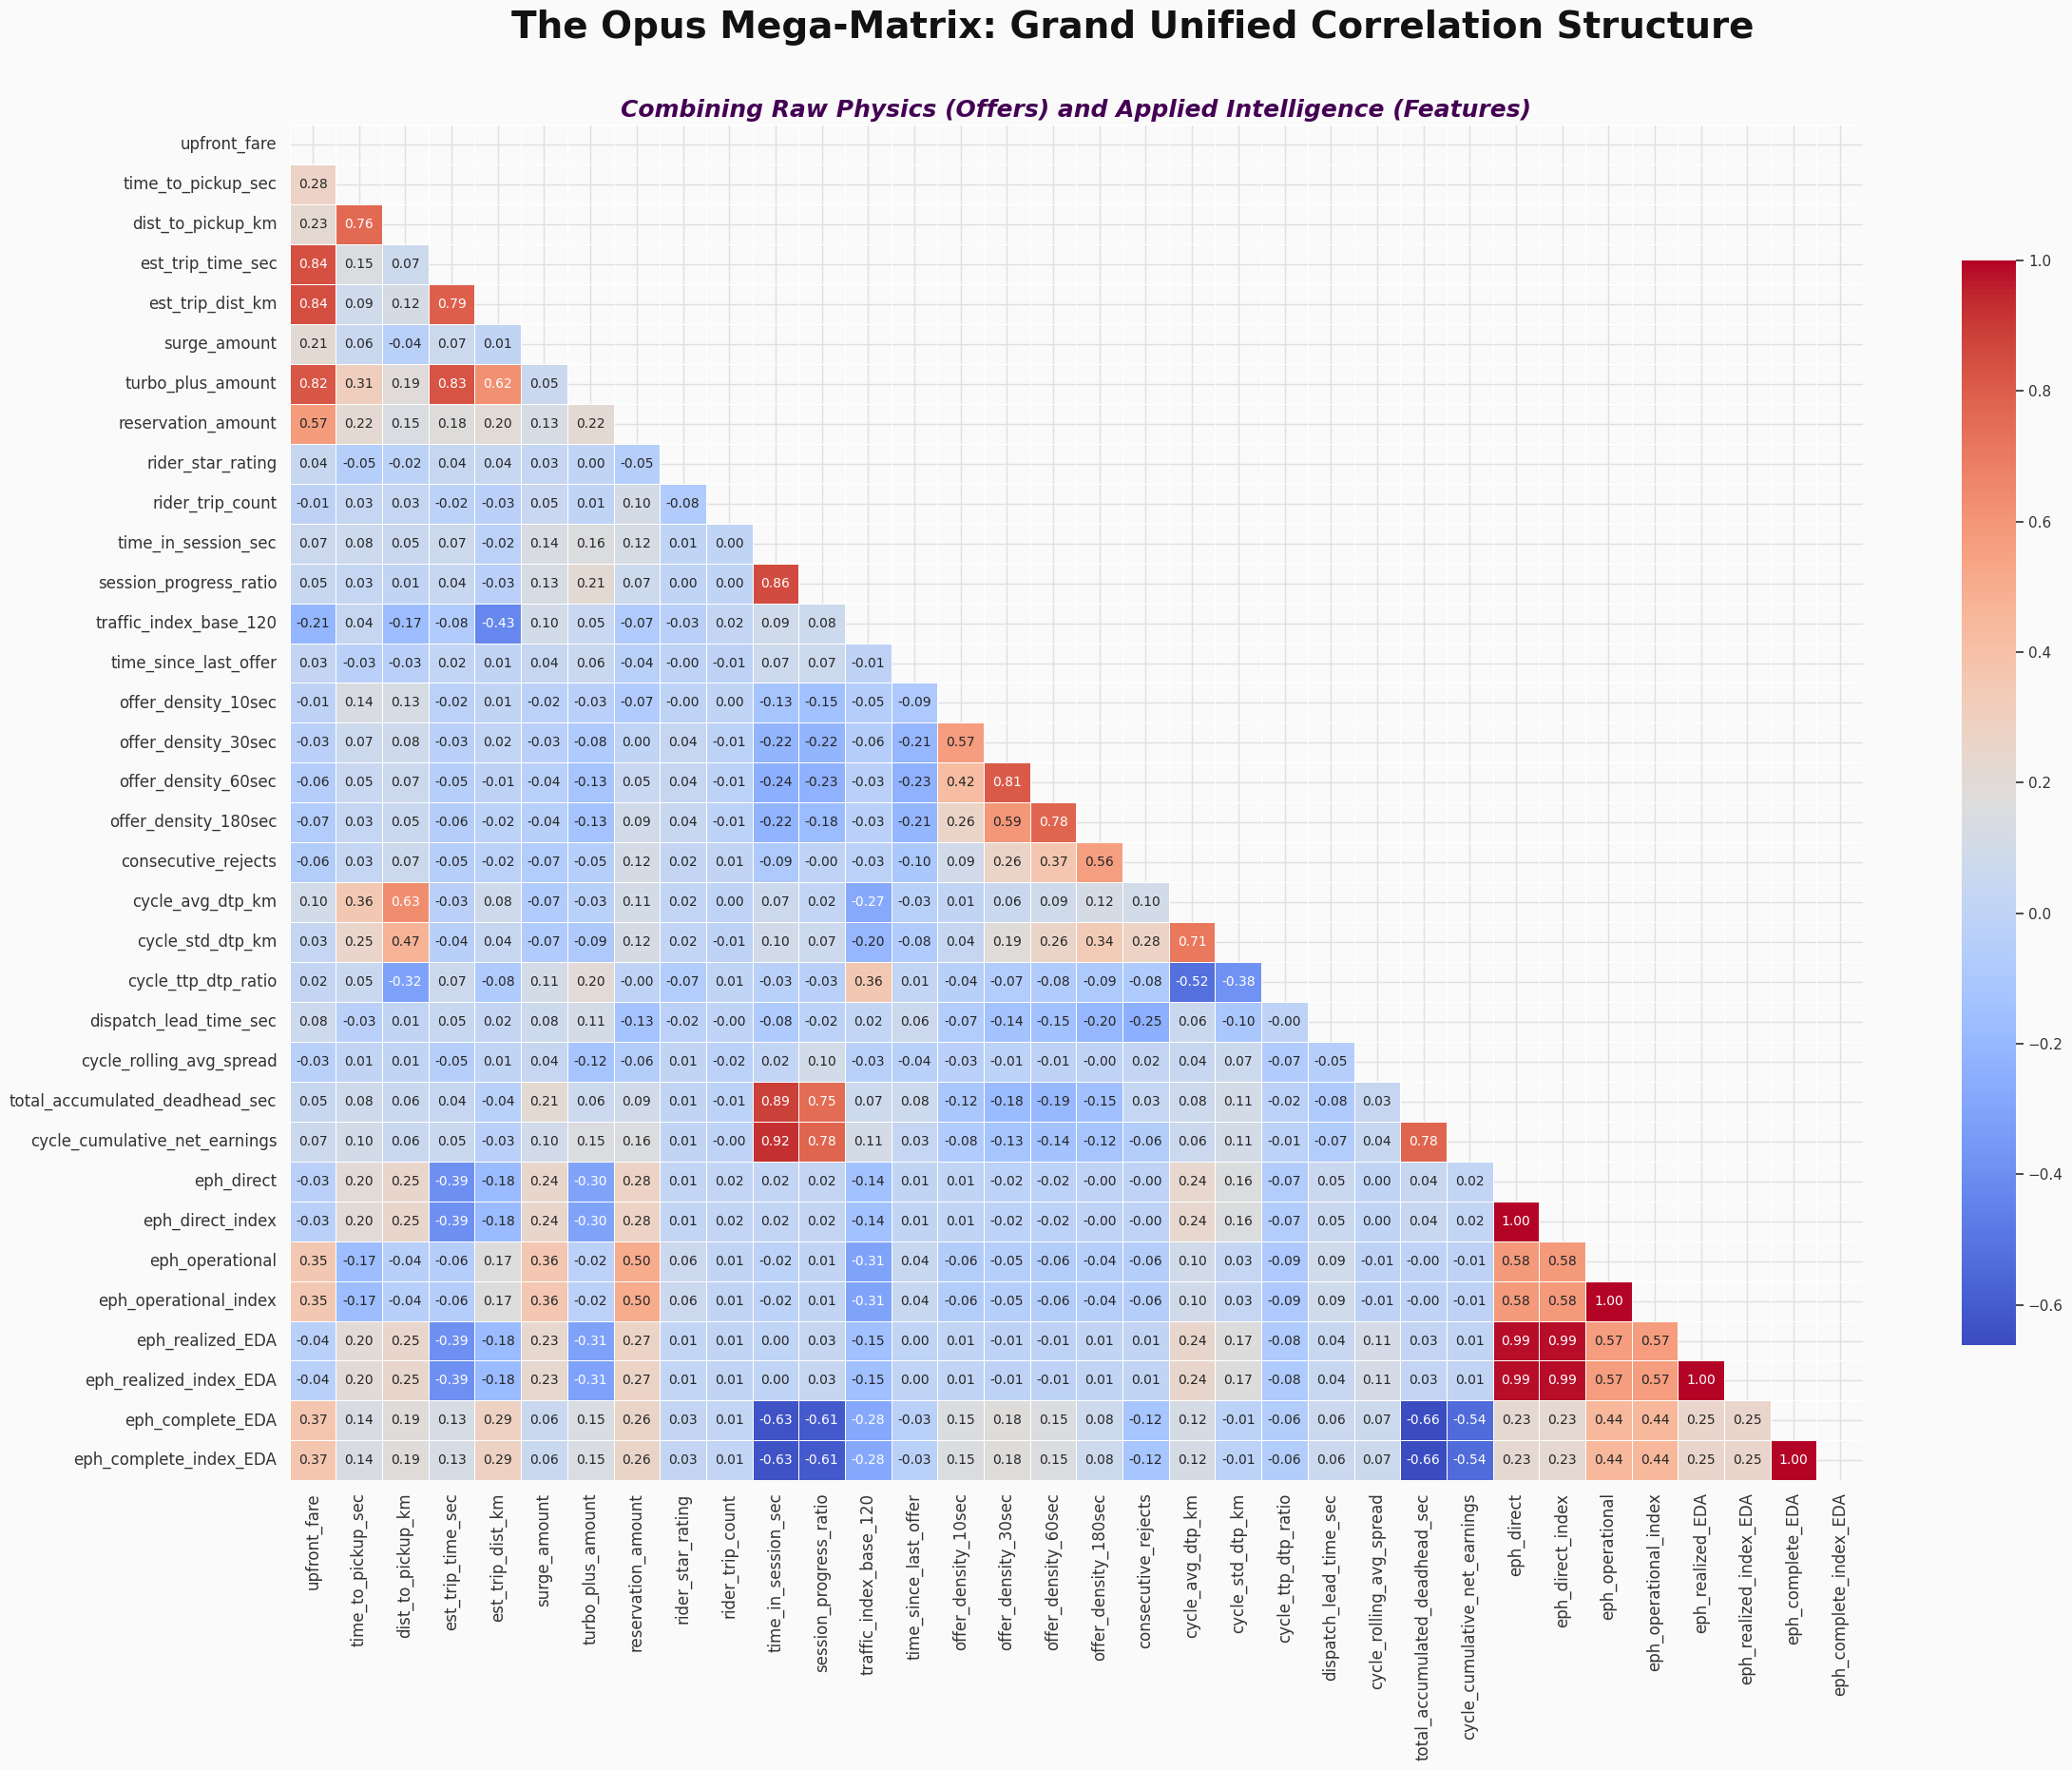


✅ Mega-Matrix Rendered.


In [7]:
# ==============================================================================
# CELL 3: THE GRAND UNIFIED CORRELATION MATRIX (MEGA-HEATMAP)
# ==============================================================================
# Purpose: 1. Join 'offers' and 'engineered_features' to create a unified dataset.
#          2. Calculate the complete correlation matrix for all key numerical vars.
#          3. Visualize this "Mega Matrix" to reveal the total system structure
#             and identify cross-domain relationships.
# ==============================================================================

# --- 1. DATA INGESTION (Unified DataFrame) ---
print("⏳ Architecting the Unified DataFrame...")

# This query selects all numerical columns from your two source heatmaps.
mega_query = """
SELECT
    -- From "Raw Physics" (offers table)
    o.upfront_fare,
    o.time_to_pickup_sec,
    o.dist_to_pickup_km,
    o.est_trip_time_sec,
    o.est_trip_dist_km,
    o.surge_amount,
    o.turbo_plus_amount,
    o.reservation_amount,
    o.rider_star_rating,
    o.rider_trip_count,
    o.time_in_session_sec,
    o.session_progress_ratio,

    -- From "Applied Intelligence" (engineered_features table)
    ef.traffic_index_base_120,
    ef.time_since_last_offer,
    ef.offer_density_10sec,
    ef.offer_density_30sec,
    ef.offer_density_60sec,
    ef.offer_density_180sec,
    ef.consecutive_rejects,
    ef.cycle_avg_dtp_km,
    ef.cycle_std_dtp_km,
    ef.cycle_ttp_dtp_ratio,
    ef.dispatch_lead_time_sec,
    ef.cycle_rolling_avg_spread,
    ef.total_accumulated_deadhead_sec,
    ef.cycle_cumulative_net_earnings,
    ef.eph_direct,
    ef.eph_direct_index,
    ef.eph_operational,
    ef.eph_operational_index,
    ef.eph_realized_EDA,
    ef.eph_realized_index_EDA,
    ef.eph_complete_EDA,
    ef.eph_complete_index_EDA

FROM offers o
LEFT JOIN engineered_features ef ON o.offer_id = ef.offer_id_fk
"""

df_mega = pd.read_sql(mega_query, db_engine)
print(f"✅ Unified DataFrame created. Shape: {df_mega.shape}")


# --- 2. CORRELATION CALCULATION ---
print("⏳ Calculating the Grand Unified Correlation Matrix...")
corr_matrix = df_mega.corr()
print("✅ Correlation Matrix Calculated.")


# --- 3. VISUALIZATION ---
print("🎨 Rendering the Mega-Heatmap...")

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set up the matplotlib figure (large to accommodate all features)
plt.figure(figsize=(24, 20))

# Draw the heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',       # Diverging colormap for correlations
    annot=True,            # Show the correlation values
    fmt='.2f',             # Format values to two decimal places
    linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 10} # Adjust font size for readability
)

# --- 4. AESTHETICS & TITLES ---
plt.suptitle("The Opus Mega-Matrix: Grand Unified Correlation Structure", fontsize=28, y=0.96)
plt.title("Combining Raw Physics (Offers) and Applied Intelligence (Features)", fontsize=18, style='italic', color=OPUS_PURPLE)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n✅ Mega-Matrix Rendered.")